In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv('../3/train.csv',  usecols=['Age', 'Fare',  'Survived'])

In [4]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
df.isnull().mean()

Survived    0.000000
Age         0.198653
Fare        0.000000
dtype: float64

In [6]:
X = df.drop(columns=['Fare'])
y = df['Fare']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y, 
    test_size=0.2,
    random_state=42
)

In [8]:
print(X_train.columns)

Index(['Survived', 'Age'], dtype='object')


In [9]:
X_train['Age_99'] = X_train['Age'].fillna(99)
X_train['Age_minus1'] = X_train['Age'].fillna(-1)

X_train['Survived_999'] = X_train['Survived'].fillna(999)
X_train['Survived_minus1'] = X_train['Survived'].fillna(-1)

In [10]:
print('Original Age variable variance: ', X_train['Age'].var())
print('Age Variance after 99 wala imputation: ', X_train['Age_99'].var())
print('Age Variance after -1 wala imputation: ', X_train['Age_minus1'].var())

print('Original Survived variable variance: ', X_train['Survived'].var())
print('Survived Variance after 999 wala imputation: ', X_train['Survived_999'].var())
print('Survived Variance after -1 wala imputation: ', X_train['Survived_minus1'].var())

Original Age variable variance:  210.2517072477435
Age Variance after 99 wala imputation:  932.9665366701432
Age Variance after -1 wala imputation:  315.9955036260055
Original Survived variable variance:  0.23505428341155837
Survived Variance after 999 wala imputation:  0.23505428341155837
Survived Variance after -1 wala imputation:  0.23505428341155837


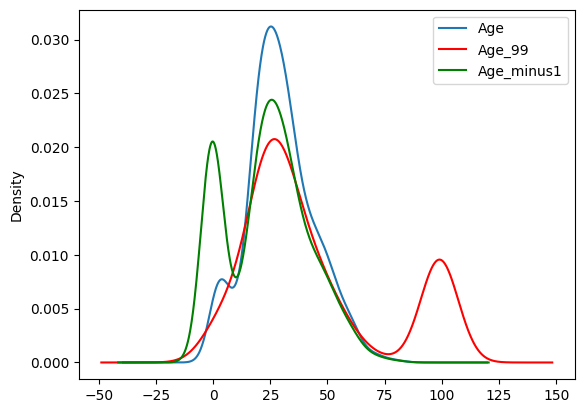

In [11]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['Age'].plot(kind='kde', ax=ax)

# variable imputed with the median
X_train['Age_99'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
X_train['Age_minus1'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

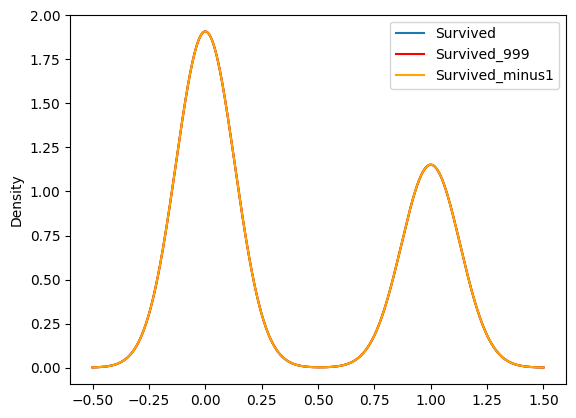

In [12]:
fig = plt.figure()
ax = fig.add_subplot(111)

X_train['Survived'].plot(kind='kde', ax=ax)

X_train['Survived_999'].plot(kind='kde', ax=ax, color='red')

X_train['Survived_minus1'].plot(kind='kde', ax=ax, color='orange')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

In [13]:
X_train.cov()

,Survived,Age,Age_99,Age_minus1,Survived_999,Survived_minus1
Survived,0.235054,-0.425381,-1.973737,0.374593,0.235054,0.235054
Age,-0.425381,210.251707,210.251707,210.251707,-0.425381,-0.425381
Age_99,-1.973737,210.251707,932.966537,-166.460682,-1.973737,-1.973737
Age_minus1,0.374593,210.251707,-166.460682,315.995504,0.374593,0.374593
Survived_999,0.235054,-0.425381,-1.973737,0.374593,0.235054,0.235054
Survived_minus1,0.235054,-0.425381,-1.973737,0.374593,0.235054,0.235054


In [14]:
X_train.corr()

,Survived,Age,Age_99,Age_minus1,Survived_999,Survived_minus1
Survived,1.000000,-0.059695,-0.133282,0.043465,1.000000,1.000000
Age,-0.059695,1.000000,1.000000,1.000000,-0.059695,-0.059695
Age_99,-0.133282,1.000000,1.000000,-0.306576,-0.133282,-0.133282
Age_minus1,0.043465,1.000000,-0.306576,1.000000,0.043465,0.043465
Survived_999,1.000000,-0.059695,-0.133282,0.043465,1.000000,1.000000
Survived_minus1,1.000000,-0.059695,-0.133282,0.043465,1.000000,1.000000


## Using Sklearn

In [15]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [16]:
imputer1 = SimpleImputer(strategy='constant', fill_value=99)
imputer2 = SimpleImputer(strategy='constant', fill_value=999)

In [17]:
# Create a ColumnTransformer to apply different imputers to different columns

trf = ColumnTransformer([
    
    # Apply imputer1 on the 'Age' column
    ('imputer1', imputer1, ['Age']),
    
    # Apply imputer2 on the 'Survived' column
    ('imputer2', imputer2, ['Survived'])
    
], remainder='passthrough')  # Keep all remaining columns unchanged

In [19]:
trf.fit(X_train)

,transformers,"[('imputer1', ...), ('imputer2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'constant'
,fill_value,99


In [20]:
trf.named_transformers_['imputer1'].statistics_

array([99.])

In [21]:
trf.named_transformers_['imputer2'].statistics_

array([999])

In [22]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [23]:
X_train

array([[40.,  0.],
       [ 4.,  1.],
       [47.,  0.],
       ...,
       [71.,  0.],
       [99.,  0.],
       [99.,  0.]], shape=(712, 2))